In [ ]:
# Week 1 - Data Acquisition, Cleaning and Preprocessing

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load the publicly available Titanic dataset
df = sns.load_dataset("titanic")

# Display the first 5 rows
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
# Check the size of the dataset
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# Display column names
print("\nColumn names:")
print(df.columns.tolist())

# Display basic information
print("\nDataset information:")
df.info()

Number of rows: 891
Number of columns: 15

Column names:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non

In [ ]:
# Check missing values
print("Missing values in each column:")
print(df.isnull().sum())

# Check duplicate rows
print("\nNumber of duplicate rows:", df.duplicated().sum())

# Statistical summary
print("\nStatistical summary:")
display(df.describe())

Missing values in each column:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Number of duplicate rows: 107

Statistical summary:


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
# Calculate missing values and their percentages

missing_count = df.isnull().sum()
missing_percentage = (missing_count / len(df)) * 100

missing_data = pd.DataFrame({
    "Missing Values": missing_count,
    "Percentage": missing_percentage
})

missing_data = missing_data[missing_data["Missing Values"] > 0]

print("Missing Value Analysis:")
display(missing_data)

Missing Value Analysis:


,Missing Values,Percentage
age,177,19.865320
embarked,2,0.224467
deck,688,77.216611
embark_town,2,0.224467


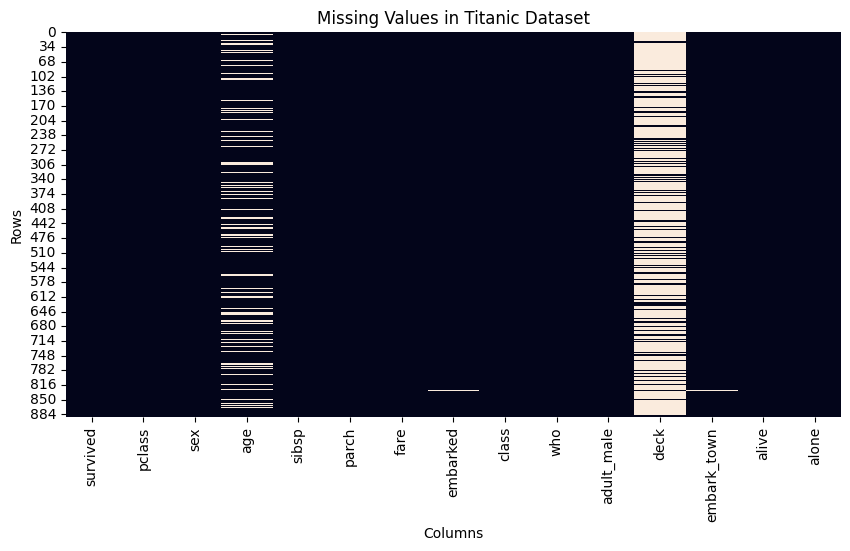

In [ ]:
# Visualize missing values

plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values in Titanic Dataset")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

In [ ]:
# Calculate missing values and their percentages

missing_count = df.isnull().sum()
missing_percentage = (missing_count / len(df)) * 100

missing_data = pd.DataFrame({
    "Missing Values": missing_count,
    "Percentage": missing_percentage.round(2)
})

missing_data = missing_data[missing_data["Missing Values"] > 0]

print("Missing Value Analysis:")
display(missing_data)

Missing Value Analysis:


,Missing Values,Percentage
age,177,19.87
embarked,2,0.22
deck,688,77.22
embark_town,2,0.22


In [ ]:
# Inspect duplicate records

duplicates = df[df.duplicated(keep=False)]

print("Total duplicate rows:", df.duplicated().sum())

print("\nSample of duplicate records:")
display(duplicates.head(20))

Total duplicate rows: 107

Sample of duplicate records:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
26,0,3,male,NaN,0,0,7.2250,C,Third,man,True,NaN,Cherbourg,no,True
28,1,3,female,NaN,0,0,7.8792,Q,Third,woman,False,NaN,Queenstown,yes,True
29,0,3,male,NaN,0,0,7.8958,S,Third,man,True,NaN,Southampton,no,True
32,1,3,female,NaN,0,0,7.7500,Q,Third,woman,False,NaN,Queenstown,yes,True
37,0,3,male,21.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
42,0,3,male,NaN,0,0,7.8958,C,Third,man,True,NaN,Cherbourg,no,True
45,0,3,male,NaN,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
46,0,3,male,NaN,1,0,15.5000,Q,Third,man,True,NaN,Queenstown,no,False
47,1,3,female,NaN,0,0,7.7500,Q,Third,woman,False,NaN,Queenstown,yes,True


In [ ]:
# Check unique values in important categorical columns

print("Sex values:")
print(df["sex"].value_counts())

print("\nEmbarked values:")
print(df["embarked"].value_counts())

print("\nClass values:")
print(df["class"].value_counts())

print("\nWho values:")
print(df["who"].value_counts())

Sex values:
sex
male      577
female    314
Name: count, dtype: int64

Embarked values:
embarked
S    644
C    168
Q     77
Name: count, dtype: int64

Class values:
class
Third     491
First     216
Second    184
Name: count, dtype: int64

Who values:
who
man      537
woman    271
child     83
Name: count, dtype: int64


In [ ]:
# Create a copy of the original dataset for cleaning
df_clean = df.copy()

# 1. Fill missing Age values with the median
age_median = df_clean["age"].median()
df_clean["age"] = df_clean["age"].fillna(age_median)

# 2. Fill missing Embarked values with the mode
embarked_mode = df_clean["embarked"].mode()[0]
df_clean["embarked"] = df_clean["embarked"].fillna(embarked_mode)

# 3. Fill missing Embark Town values with the mode
embark_town_mode = df_clean["embark_town"].mode()[0]
df_clean["embark_town"] = df_clean["embark_town"].fillna(embark_town_mode)

# 4. Remove the Deck column because 77.22% of its values are missing
df_clean = df_clean.drop(columns=["deck"])

print("Missing values after cleaning:")
print(df_clean.isnull().sum())

Missing values after cleaning:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


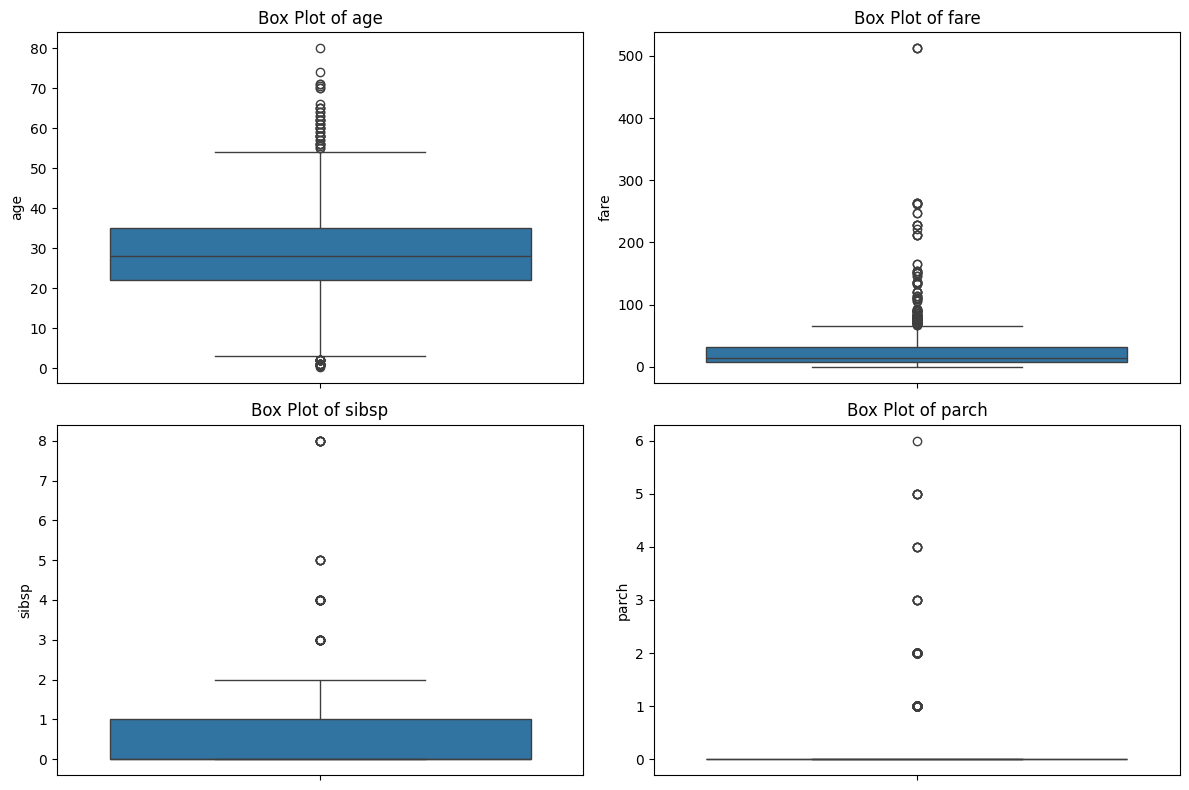

In [ ]:
# Outlier detection using box plots

numerical_columns = ["age", "fare", "sibsp", "parch"]

plt.figure(figsize=(12, 8))

for i, column in enumerate(numerical_columns, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=df_clean[column])
    plt.title(f"Box Plot of {column}")

plt.tight_layout()
plt.show()

In [ ]:
# Detect outliers using the IQR method

for column in numerical_columns:
    Q1 = df_clean[column].quantile(0.25)
    Q3 = df_clean[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_clean[
        (df_clean[column] < lower_bound) |
        (df_clean[column] > upper_bound)
    ]

    print(f"{column}:")
    print(f"  Q1 = {Q1:.2f}")
    print(f"  Q3 = {Q3:.2f}")
    print(f"  IQR = {IQR:.2f}")
    print(f"  Lower Bound = {lower_bound:.2f}")
    print(f"  Upper Bound = {upper_bound:.2f}")
    print(f"  Number of outliers = {len(outliers)}")
    print()

age:
  Q1 = 22.00
  Q3 = 35.00
  IQR = 13.00
  Lower Bound = 2.50
  Upper Bound = 54.50
  Number of outliers = 66

fare:
  Q1 = 7.91
  Q3 = 31.00
  IQR = 23.09
  Lower Bound = -26.72
  Upper Bound = 65.63
  Number of outliers = 116

sibsp:
  Q1 = 0.00
  Q3 = 1.00
  IQR = 1.00
  Lower Bound = -1.50
  Upper Bound = 2.50
  Number of outliers = 46

parch:
  Q1 = 0.00
  Q3 = 0.00
  IQR = 0.00
  Lower Bound = 0.00
  Upper Bound = 0.00
  Number of outliers = 213



In [ ]:
# Create an outlier summary table

outlier_summary = []

for column in numerical_columns:
    Q1 = df_clean[column].quantile(0.25)
    Q3 = df_clean[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = (
        (df_clean[column] < lower_bound) |
        (df_clean[column] > upper_bound)
    ).sum()

    outlier_summary.append({
        "Column": column,
        "Q1": round(Q1, 2),
        "Q3": round(Q3, 2),
        "IQR": round(IQR, 2),
        "Lower Bound": round(lower_bound, 2),
        "Upper Bound": round(upper_bound, 2),
        "Outlier Count": int(outlier_count),
        "Treatment": "Retained - plausible values"
    })

outlier_summary_df = pd.DataFrame(outlier_summary)

display(outlier_summary_df)

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Treatment
0,age,22.00,35.0,13.00,2.50,54.50,66,Retained - plausible values
1,fare,7.91,31.0,23.09,-26.72,65.63,116,Retained - plausible values
2,sibsp,0.00,1.0,1.00,-1.50,2.50,46,Retained - plausible values
3,parch,0.00,0.0,0.00,0.00,0.00,213,Retained - plausible values


In [ ]:
# Compare original and cleaned dataset

print("Original dataset shape:", df.shape)
print("Cleaned dataset shape:", df_clean.shape)

print("\nTotal missing values before cleaning:",
      df.isnull().sum().sum())

print("Total missing values after cleaning:",
      df_clean.isnull().sum().sum())

print("\nColumns removed:")
print(set(df.columns) - set(df_clean.columns))

print("\nFirst 5 rows of cleaned dataset:")
display(df_clean.head())

Original dataset shape: (891, 15)
Cleaned dataset shape: (891, 14)

Total missing values before cleaning: 869
Total missing values after cleaning: 0

Columns removed:
{'deck'}

First 5 rows of cleaned dataset:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


In [ ]:
# Create a separate dataframe for preprocessing
df_processed = df_clean.copy()

# Convert boolean columns to integers
df_processed["adult_male"] = df_processed["adult_male"].astype(int)
df_processed["alone"] = df_processed["alone"].astype(int)

# One-hot encode categorical columns
categorical_columns = [
    "sex",
    "embarked",
    "class",
    "who",
    "embark_town",
    "alive"
]

df_processed = pd.get_dummies(
    df_processed,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)

print("Processed dataset shape:", df_processed.shape)

print("\nData types after preprocessing:")
print(df_processed.dtypes)

print("\nFirst 5 rows:")
display(df_processed.head())

Processed dataset shape: (891, 18)

Data types after preprocessing:
survived                     int64
pclass                       int64
age                        float64
sibsp                        int64
parch                        int64
fare                       float64
adult_male                   int64
alone                        int64
sex_male                     int64
embarked_Q                   int64
embarked_S                   int64
class_Second                 int64
class_Third                  int64
who_man                      int64
who_woman                    int64
embark_town_Queenstown       int64
embark_town_Southampton      int64
alive_yes                    int64
dtype: object

First 5 rows:


,survived,pclass,age,sibsp,parch,fare,adult_male,alone,sex_male,embarked_Q,embarked_S,class_Second,class_Third,who_man,who_woman,embark_town_Queenstown,embark_town_Southampton,alive_yes
0,0,3,22.0,1,0,7.2500,1,0,1,0,1,0,1,1,0,0,1,0
1,1,1,38.0,1,0,71.2833,0,0,0,0,0,0,0,0,1,0,0,1
2,1,3,26.0,0,0,7.9250,0,1,0,0,1,0,1,0,1,0,1,1
3,1,1,35.0,1,0,53.1000,0,0,0,0,1,0,0,0,1,0,1,1
4,0,3,35.0,0,0,8.0500,1,1,1,0,1,0,1,1,0,0,1,0


In [ ]:
# Final data quality validation

print("========== FINAL DATA QUALITY CHECK ==========")

print("\n1. Dataset shape:")
print("Rows:", df_processed.shape[0])
print("Columns:", df_processed.shape[1])

print("\n2. Total missing values:")
print(df_processed.isnull().sum().sum())

print("\n3. Total duplicate rows:")
print(df_processed.duplicated().sum())

print("\n4. Data types:")
print(df_processed.dtypes)

print("\n5. Numeric columns:")
print(df_processed.select_dtypes(include=np.number).columns.tolist())

print("\n6. Final preview:")
display(df_processed.head())

========== FINAL DATA QUALITY CHECK ==========

1. Dataset shape:
Rows: 891
Columns: 18

2. Total missing values:
0

3. Total duplicate rows:
116

4. Data types:
survived                     int64
pclass                       int64
age                        float64
sibsp                        int64
parch                        int64
fare                       float64
adult_male                   int64
alone                        int64
sex_male                     int64
embarked_Q                   int64
embarked_S                   int64
class_Second                 int64
class_Third                  int64
who_man                      int64
who_woman                    int64
embark_town_Queenstown       int64
embark_town_Southampton      int64
alive_yes                    int64
dtype: object

5. Numeric columns:
['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'adult_male', 'alone', 'sex_male', 'embarked_Q', 'embarked_S', 'class_Second', 'class_Third', 'who_man', 'who_woman',

,survived,pclass,age,sibsp,parch,fare,adult_male,alone,sex_male,embarked_Q,embarked_S,class_Second,class_Third,who_man,who_woman,embark_town_Queenstown,embark_town_Southampton,alive_yes
0,0,3,22.0,1,0,7.2500,1,0,1,0,1,0,1,1,0,0,1,0
1,1,1,38.0,1,0,71.2833,0,0,0,0,0,0,0,0,1,0,0,1
2,1,3,26.0,0,0,7.9250,0,1,0,0,1,0,1,0,1,0,1,1
3,1,1,35.0,1,0,53.1000,0,0,0,0,1,0,0,0,1,0,1,1
4,0,3,35.0,0,0,8.0500,1,1,1,0,1,0,1,1,0,0,1,0


In [ ]:
# Save the cleaned and processed dataset

df_processed.to_csv(
    "titanic_cleaned_processed.csv",
    index=False
)

print("Cleaned dataset saved successfully.")
print("File name: titanic_cleaned_processed.csv")

Cleaned dataset saved successfully.
File name: titanic_cleaned_processed.csv


In [ ]:
# Before vs After comparison

comparison = pd.DataFrame({
    "Metric": [
        "Number of rows",
        "Number of columns",
        "Total missing values",
        "Duplicate rows",
        "Deck column"
    ],
    "Before Cleaning": [
        df.shape[0],
        df.shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum(),
        "Present"
    ],
    "After Cleaning": [
        df_clean.shape[0],
        df_clean.shape[1],
        df_clean.isnull().sum().sum(),
        df_clean.duplicated().sum(),
        "Removed"
    ]
})

display(comparison)

,Metric,Before Cleaning,After Cleaning
0,Number of rows,891,891
1,Number of columns,15,14
2,Total missing values,869,0
3,Duplicate rows,107,116
4,Deck column,Present,Removed


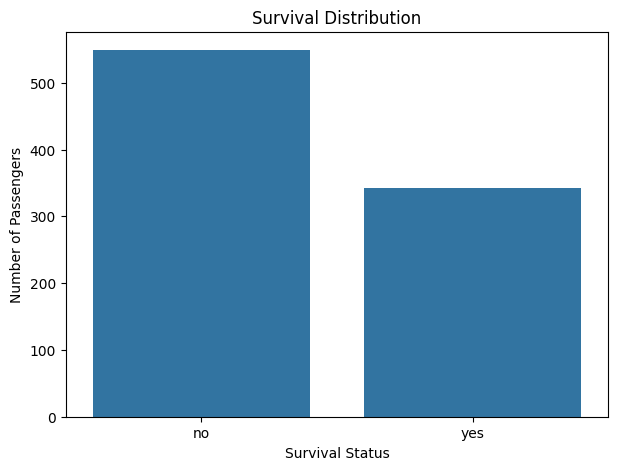

In [ ]:
# Distribution of survival outcomes

plt.figure(figsize=(7, 5))
sns.countplot(data=df_clean, x="alive")
plt.title("Survival Distribution")
plt.xlabel("Survival Status")
plt.ylabel("Number of Passengers")
plt.show()

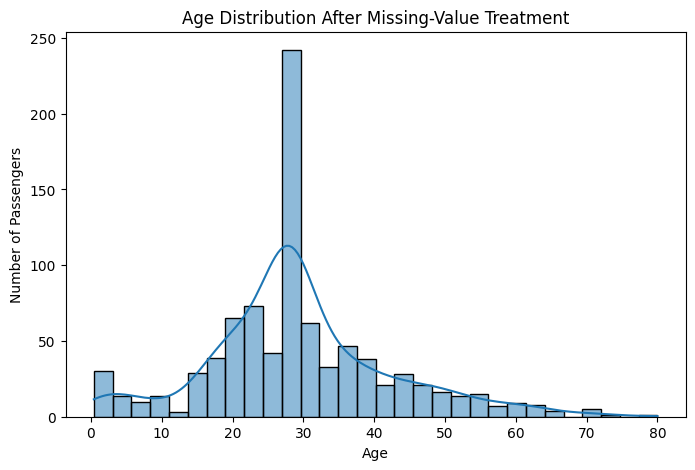

In [ ]:
# Distribution of passenger ages after cleaning

plt.figure(figsize=(8, 5))
sns.histplot(df_clean["age"], bins=30, kde=True)
plt.title("Age Distribution After Missing-Value Treatment")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()

In [ ]:
# Remove the redundant 'alive' feature for a modelling-ready dataset

df_model_ready = df_clean.drop(columns=["alive"])

print("Modelling-ready dataset shape:", df_model_ready.shape)
print("\nRemaining columns:")
print(df_model_ready.columns.tolist())

Modelling-ready dataset shape: (891, 13)

Remaining columns:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alone']
